<a href="https://colab.research.google.com/github/shifanabila3434-max/Shifa-Nabila/blob/main/Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten

In [ ]:
arial_path = '/content/drive/MyDrive/Font Dataset Large/Arial'
Brandish_path = '/content/drive/MyDrive/Font Dataset Large/Brandish'
Consolas_path = '/content/drive/MyDrive/Font Dataset Large/Consolas'
Didot_path = '/content/drive/MyDrive/Font Dataset Large/Didot'

In [ ]:
arial_filenames = os.listdir('/content/drive/MyDrive/Font Dataset Large/Arial')
brandish_filenames = os.listdir('/content/drive/MyDrive/Font Dataset Large/Brandish')
consolas_filenames = os.listdir('/content/drive/MyDrive/Font Dataset Large/Consolas')
didot_filenames = os.listdir('/content/drive/MyDrive/Font Dataset Large/Didot')

In [ ]:
arial_filenames [:5]

['Image_1467.jpg',
 'Image_1471.jpg',
 'Image_1466.jpg',
 'Image_1473.jpg',
 'Image_1464.jpg']

In [ ]:
def load_image(filenames, path):
    images = []
    for filename in tqdm(filenames):
        image = cv2.imread(path + '/' + filename)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        images.append(image)

    return images

In [ ]:
import os

base_path = '/content/drive/MyDrive/Font Dataset Large'

for folder in os.listdir(base_path):
    print(folder, len(os.listdir(os.path.join(base_path, folder))))

Consolas 3609
Didot 5000
Arial 5000
Brandish 5000


In [ ]:
arial_images = load_image(arial_filenames, arial_path)
brandish_images = load_image(brandish_filenames, Brandish_path)
consolas_images = load_image(consolas_filenames, Consolas_path)
didot_images = load_image(didot_filenames, Didot_path)

100%|██████████| 5000/5000 [30:22<00:00,  2.74it/s]


In [ ]:
heights = []
widths = []

for image in arial_images:
    height = image.shape[0]
    width = image.shape[1]

    heights.append(height)
    widths.append(width)

print('max_h: {}, min_h: {}'.format(max(heights), min(heights)))
print('max_w: {}, min_w: {}'.format(max(widths), min(widths)))

max_h: 32, min_h: 32
max_w: 248, min_w: 30


In [ ]:
def take_80_pixels(images_list):
    new_images = []
    for image in images_list:
        if image.shape[1] >= 80:
            new_images.append(image[:, :80])
        else:
            pass

    return np.array(new_images)

In [ ]:
arial_80 = take_80_pixels(arial_images)
brandish_80 = take_80_pixels(brandish_images)
consolas_80 = take_80_pixels(consolas_images)
didot_80 = take_80_pixels(didot_images)

In [ ]:
print(arial_80.shape)
print(brandish_80.shape)
print(consolas_80.shape)
print(didot_80.shape)

(4079, 32, 80)
(4028, 32, 80)
(4741, 32, 80)
(3920, 32, 80)


In [ ]:
all_images = np.append(arial_80, brandish_80, axis=0)
all_images = np.append(all_images, consolas_80, axis=0)
all_images = np.append(all_images, didot_80, axis=0)
all_images.shape

(16768, 32, 80)

In [ ]:
all_images = all_images.reshape(all_images.shape[0],
                               all_images.shape[1],
                               all_images.shape[2],
                               1)

print(all_images.shape)

(16768, 32, 80, 1)


In [ ]:
labels = [0]*len(arial_80) + \
         [1]*len(brandish_80) + \
         [2]*len(consolas_80) + \
         [3]*len(didot_80)

print(len(labels))

16768


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(all_images,
                                                    labels,
                                                    test_size=0.3,
                                                    random_state=88)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
y_train = y_train[:, np.newaxis]
y_test = y_test[:, np.newaxis]

In [ ]:
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = one_hot_encoder.fit_transform(y_train)
y_test_encoded = one_hot_encoder.transform(y_test)

In [ ]:
print(y_train[:5])

[[1]
 [3]
 [0]
 [3]
 [3]]


In [ ]:
print(y_train_encoded[:5])

[[0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]


In [ ]:
input_shape = (all_images.shape[1],
              all_images.shape[2],
              1)

In [ ]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu',
                 padding='same', input_shape=input_shape))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(2, 2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(50, activation='relu'))
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 80, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 37440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     3,744,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,768,170 (14.37 MB)

 Trainable params: 3,768,170 (14.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train_encoded,
    epochs=3,
    validation_data=(X_test, y_test_encoded)
)

Epoch 1/3
367/367 ━━━━━━━━━━━━━━━━━━━━ 144s 387ms/step - accuracy: 0.9594 - loss: 4.7547 - val_accuracy: 0.9986 - val_loss: 0.0101
Epoch 2/3
367/367 ━━━━━━━━━━━━━━━━━━━━ 141s 384ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9994 - val_loss: 0.0016
Epoch 3/3
367/367 ━━━━━━━━━━━━━━━━━━━━ 134s 366ms/step - accuracy: 1.0000 - loss: 8.4618e-06 - val_accuracy: 0.9996 - val_loss: 0.0011


In [ ]:
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)

print(predictions)

158/158 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step
[1 3 3 ... 1 1 2]


In [ ]:
y_test = y_test.reshape(y_test.shape[0])

print(y_test)

[1 3 3 ... 1 1 2]


<Axes: >

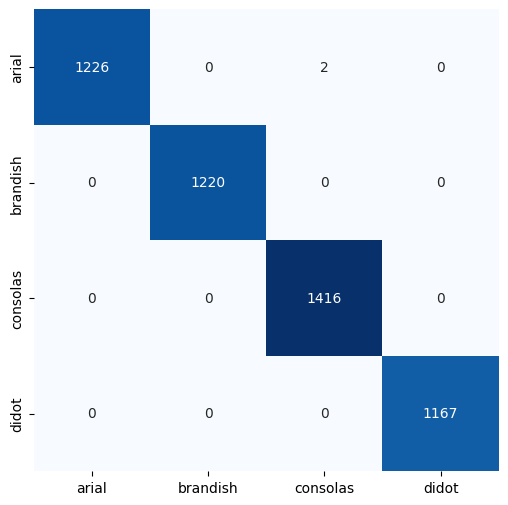

In [ ]:
cm = confusion_matrix(y_test, predictions)

label_names = ['arial', 'brandish', 'consolas', 'didot']

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=label_names, yticklabels=label_names,
            cmap=plt.cm.Blues)

In [ ]:
misses = []

for i in range(len(predictions)):
    if y_test[i] != predictions[i]:
        misses.append(i)

print(misses)

[231, 1118]


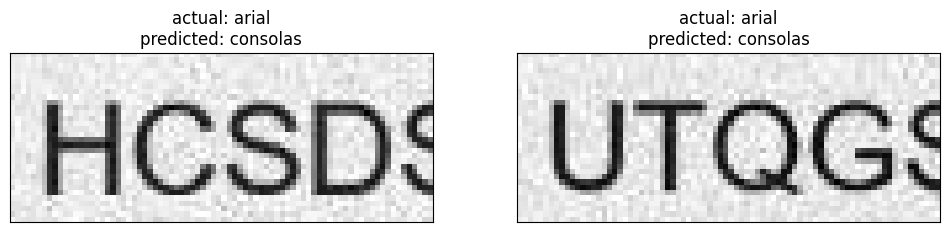

In [ ]:
fig, axes = plt.subplots(ncols=2, sharex=False, figsize=(12, 3))

for i, miss in zip(range(2), misses):
    axes[i].set_title('actual: {}\npredicted: {}'.format(
        str(label_names[y_test[miss]]),
        str(label_names[predictions[miss]])
    ))

    axes[i].imshow(X_test[miss], cmap='gray')
    axes[i].get_xaxis().set_visible(False)
    axes[i].get_yaxis().set_visible(False)

plt.show()